<a href="https://colab.research.google.com/github/zehrakarakas-1283/predictive-maintenance-ai/blob/main/MakineAr%C4%B1zaTahmin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


df = pd.read_csv('/content/ai4i2020.csv')

# Tablonun ilk 5 satırını ekrana yazdır
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
import numpy as np

# Veri Temizleme (Data Cleaning): Eksik değer (NaN) kontrolü
eksik_veri = df.isnull().sum().sum()
print(f"Veri setindeki toplam eksik hücre sayısı: {eksik_veri}")

# Numpy Kullanımı: Sembolik vektörel bir hesaplama
ortalama_sicaklik = np.mean(df['Air temperature [K]'])
print(f"Tesisin Ortalama Ortam Sıcaklığı: {ortalama_sicaklik:.2f} K")

Veri setindeki toplam eksik hücre sayısı: 0
Tesisin Ortalama Ortam Sıcaklığı: 300.00 K


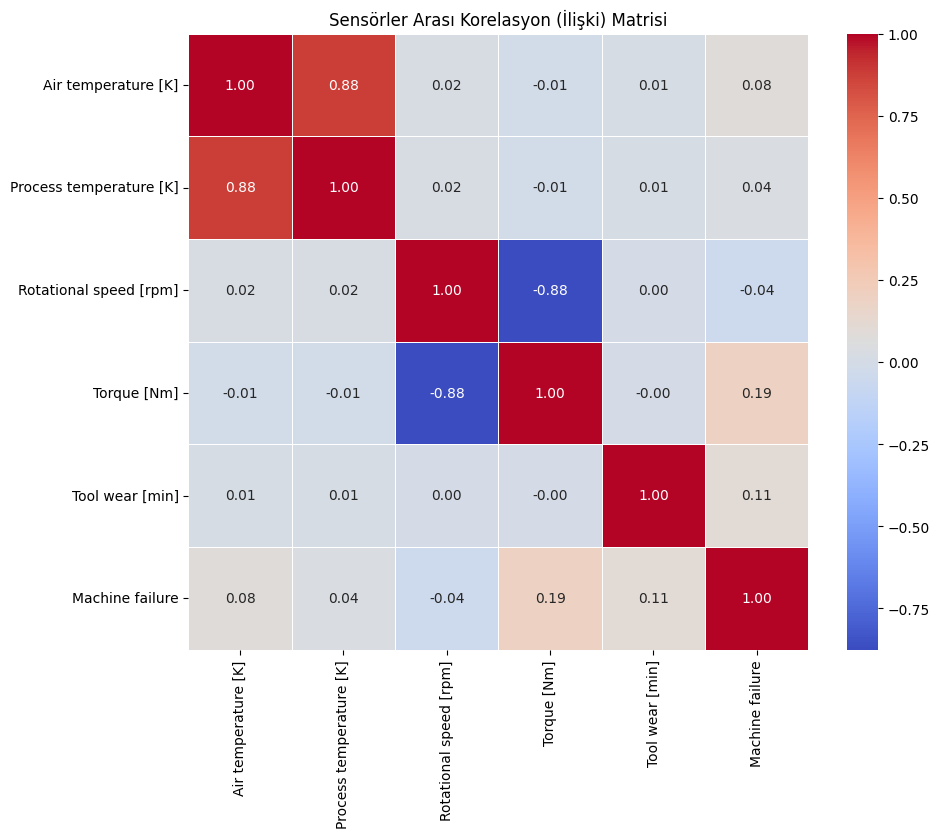

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece incelediğim sayısal sütunları seçip korelasyonlarını hesapla
plt.figure(figsize=(10, 8))
korelasyon = df[['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]',
                 'Tool wear [min]', 'Machine failure']].corr()

# Isı haritası (Heatmap) olarak çizdiriyoruz
# cmap='coolwarm': Pozitif ilişkileri kırmızı, negatifleri mavi yap
sns.heatmap(korelasyon, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Sensörler Arası Korelasyon (İlişki) Matrisi")
plt.show()

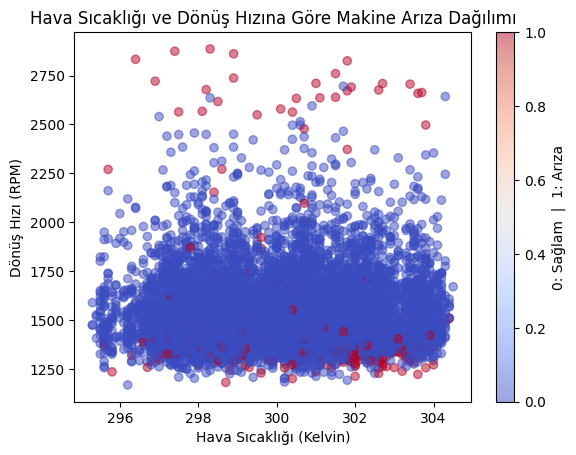

In [ ]:
import matplotlib.pyplot as plt

# X ve Y eksenlerine tablodaki verileri ata
sicaklik = df['Air temperature [K]']
hiz = df['Rotational speed [rpm]']
ariza_durumu = df['Machine failure']

# plt.scatter ile dağılım grafiğini çiz
# c=ariza_durumu ile 0 (sağlam) ve 1 (arızalı) noktaları ayır
# cmap='coolwarm' ile sağlamları mavi, arızalıları kırmızı yap
plt.scatter(sicaklik, hiz, c=ariza_durumu, cmap='coolwarm', alpha=0.5)
plt.colorbar(label='0: Sağlam  |  1: Arıza')

plt.title("Hava Sıcaklığı ve Dönüş Hızına Göre Makine Arıza Dağılımı")
plt.xlabel("Hava Sıcaklığı (Kelvin)")
plt.ylabel("Dönüş Hızı (RPM)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Harf içeren UDI, Product ID ve Type sütunlarını da çöpe at ki model sadece sayılarla çalışsın
X = df.drop(columns=['UDI', 'Product ID', 'Type', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Test verilerini modele ver tahmin yaptır
tahminler = model.predict(X_test)

# Modelin tahminlerini gerçek arıza durumlarıyla (y_test) karşılaştır
basari_orani = accuracy_score(y_test, tahminler)

print(f"Modelin Doğruluk Oranı (Accuracy): % {basari_orani * 100:.2f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, tahminler))

Modelin Doğruluk Oranı (Accuracy): % 90.75

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1939
           1       0.23      0.89      0.37        61

    accuracy                           0.91      2000
   macro avg       0.61      0.90      0.66      2000
weighted avg       0.97      0.91      0.93      2000



precision(kesinlik) arıza var dediğinde % kaçı doğru çıkıyor? precision değeri fazla evhamlı davranıp arızalı olmayan makinelere de arızalı diyebilir. Arıza olmadan "Arıza var!" uyarısıyla teknikerin fazladan kontol yapması üretim bandının sekteye uğramasından iyidir.

In [ ]:
from sklearn import set_config
set_config(display='diagram')

model

DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)

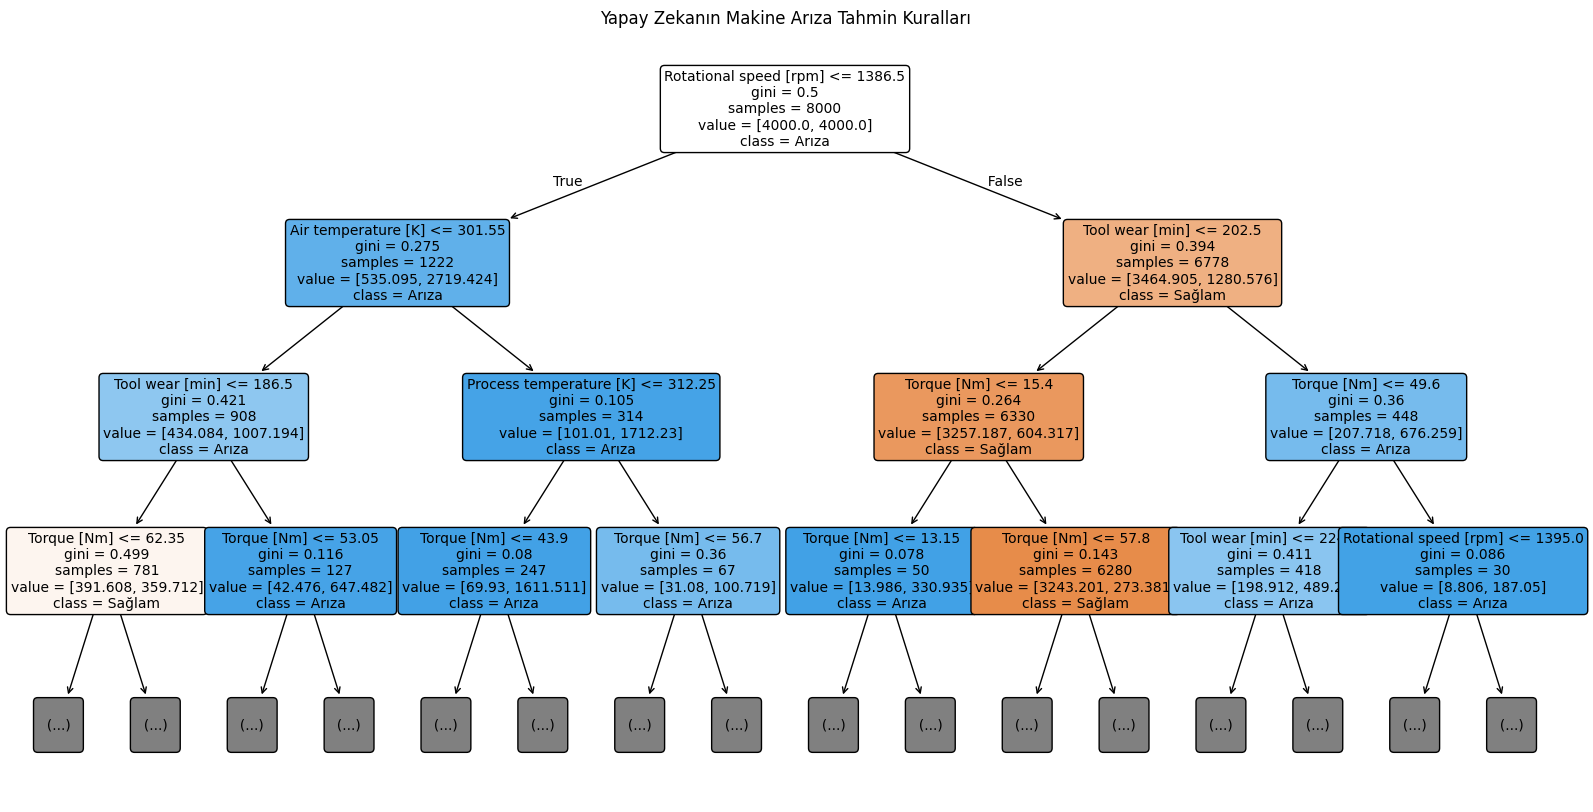

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Çizim alanını genişlet ki kutular üst üste binmesin
plt.figure(figsize=(20, 10))

# Karar Ağacı (Decision Tree) kurallarını görselleştir
# max_depth=3 diyerek ağacın sadece en önemli ilk 3 kuralını (derinliğini) çizdir
plot_tree(model,
          feature_names=X.columns,
          class_names=['Sağlam', 'Arıza'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)

plt.title("Yapay Zekanın Makine Arıza Tahmin Kuralları")
plt.show()

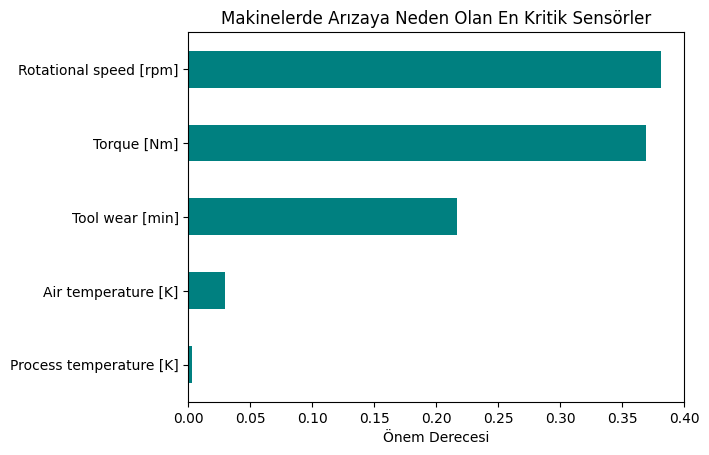

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sensörlerin karar vermedeki etki oranlarını al
onem_duzeyleri = pd.Series(model.feature_importances_, index=X.columns)

# En çok etki edenden en aza doğru sıralayıp çizdir
onem_duzeyleri.sort_values().plot(kind='barh', color='teal')

plt.title("Makinelerde Arızaya Neden Olan En Kritik Sensörler")
plt.xlabel("Önem Derecesi")
plt.show()

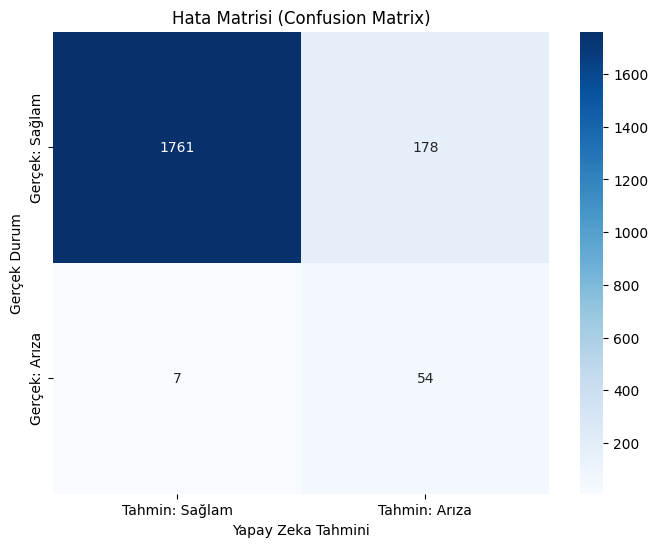

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Modelin sınav kağıdındaki (y_test) gerçek cevaplar ile kendi tahminlerini karşılaştır
cm = confusion_matrix(y_test, tahminler)

# Isı haritası (Heatmap) ile matrisi görselleştir
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: Sağlam', 'Tahmin: Arıza'],
            yticklabels=['Gerçek: Sağlam', 'Gerçek: Arıza'])

plt.title("Hata Matrisi (Confusion Matrix)")
plt.ylabel('Gerçek Durum')
plt.xlabel('Yapay Zeka Tahmini')
plt.show()

In [13]:
import pandas as pd

# 3 farklı senaryo: 1. Normal, 2. Yüksek sıcaklık/düşük hız (riskli), 3. Yüksek aşınma (riskli)
yeni_ornekler = pd.DataFrame([
    [298.1, 308.6, 1551, 42.8, 0],   # Örnek 1: Sağlam beklenen
    [302.5, 311.0, 1350, 55.0, 210], # Örnek 2: Arıza beklenen
    [299.0, 309.0, 1400, 60.0, 250]  # Örnek 3: Arıza beklenen
], columns=['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'])

ornek_tahminler = model.predict(yeni_ornekler)

print("3 Yeni Örnek Senaryo Sonuçları")
for i, sonuc in enumerate(ornek_tahminler):
    durum = "ARIZA RİSKİ ⚠️" if sonuc == 1 else "SAĞLAM ✅"
    print(f"{i+1}. Makine Senaryosu Tahmini: {durum}")

3 Yeni Örnek Senaryo Sonuçları
1. Makine Senaryosu Tahmini: SAĞLAM ✅
2. Makine Senaryosu Tahmini: ARIZA RİSKİ ⚠️
3. Makine Senaryosu Tahmini: ARIZA RİSKİ ⚠️


In [15]:
def akilli_tahmin_araci():
    print("Akıllı Makine Arıza Tahmin Aracına Hoş Geldiniz")
    try:
        air = float(input("Hava Sıcaklığı (K) girin (Örn: 298.1): "))
        process = float(input("İşlem Sıcaklığı (K) girin (Örn: 308.6): "))
        rpm = float(input("Dönüş Hızı (rpm) girin (Örn: 1551): "))
        torque = float(input("Tork (Nm) girin (Örn: 42.8): "))
        wear = float(input("Alet Aşınması (dk) girin (Örn: 0): "))

        kullanici_verisi = pd.DataFrame([[air, process, rpm, torque, wear]],
                                 columns=['Air temperature [K]', 'Process temperature [K]',
                                          'Rotational speed [rpm]', 'Torque [Nm]',
                                          'Tool wear [min]'])

        tahmin = model.predict(kullanici_verisi)[0]

        print("\n" + "="*50)
        if tahmin == 1:
            print(f"⚠️ DİKKAT! Girdiğiniz {rpm} rpm hız ve {torque} Nm tork değerlerine göre makinede ARIZA RİSKİ YÜKSEKTİR!")
        else:
            print(f"✅ Sistem stabil. Girdiğiniz değerlere göre makine SORUNSUZ çalışmaktadır.")
        print("="*50 + "\n")
    except ValueError:
        print("HATA: Lütfen sadece sayısal değerler giriniz!")

# Uygulamayı başlatmak için fonksiyonu çağır
akilli_tahmin_araci()

Akıllı Makine Arıza Tahmin Aracına Hoş Geldiniz
Hava Sıcaklığı (K) girin (Örn: 298.1): 254.8
İşlem Sıcaklığı (K) girin (Örn: 308.6): 301.4
Dönüş Hızı (rpm) girin (Örn: 1551): 1907
Tork (Nm) girin (Örn: 42.8): 53.7
Alet Aşınması (dk) girin (Örn: 0): 2

✅ Sistem stabil. Girdiğiniz değerlere göre makine SORUNSUZ çalışmaktadır.

